In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
world = gpd.read_file("ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Admin-0 country,1,3,Yemen,YEM,0,2,Sovereign country,1,Yemen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Admin-0 country,3,2,Vietnam,VNM,0,2,Sovereign country,1,Vietnam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Admin-0 country,5,3,Venezuela,VEN,0,2,Sovereign country,1,Venezuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


In [4]:
world = world.rename(columns = {'ADMIN':'Country'})

In [6]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'Country',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [7]:
africa_gdp = pd.read_csv("Data_Africa.csv")
africa_gdp.head()

,ID,Year,Country,Continent,Population,GDP (USD)
0,1,2000,Uganda,East Africa,23303189,6.193247e+09
1,2,2001,Uganda,East Africa,24022603,5.840504e+09
2,3,2002,Uganda,East Africa,24781316,5.840504e+09
3,4,2003,Uganda,East Africa,25577246,6.606884e+09
4,5,2004,Uganda,East Africa,26403221,7.939488e+09


In [8]:
africa_gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           1334 non-null   int64  
 1   Year         1334 non-null   int64  
 2   Country      1334 non-null   str    
 3   Continent    1334 non-null   str    
 4   Population   1334 non-null   int64  
 5   GDP (USD)    1179 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 62.7 KB


In [9]:
africa_gdp.isnull().sum()

ID               0
Year             0
Country          0
Continent        0
Population       0
GDP (USD)      155
dtype: int64

In [11]:
africa_gdp = africa_gdp.dropna(subset = ['GDP (USD)'])

In [13]:
africa_gdp.isnull().sum()

ID             0
Year           0
Country        0
Continent      0
Population     0
GDP (USD)      0
dtype: int64

In [14]:
africa_gdp.Year.unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022])

In [16]:
gdp_2022 = africa_gdp.query('Year == 2022')
gdp_2022

,ID,Year,Country,Continent,Population,GDP (USD)
22,23,2022,Uganda,East Africa,47992685,4.555920e+10
45,46,2022,Burundi,East Africa,12504404,3.073415e+09
68,69,2022,Djibouti,East Africa,1007062,3.515109e+09
91,92,2022,Zambia,East Africa,19244849,2.978445e+10
114,115,2022,Zimbabwe,East Africa,15412353,2.067806e+10
137,138,2022,Kenya,East Africa,56031570,1.134200e+11
160,161,2022,Union of the Comors,East Africa,902348,1.242519e+09
183,184,2022,Mauritius,East Africa,1280936,1.289831e+10
206,207,2022,Madagascar,East Africa,28876295,1.495497e+10
252,253,2022,Malawi,East Africa,20053121,1.316467e+10


In [17]:
gdp_2022.Country.unique()

<StringArray>
[                          'Uganda',                          'Burundi',
                         'Djibouti',                           'Zambia',
                         'Zimbabwe',                            'Kenya',
              'Union of the Comors',                        'Mauritius',
                       'Madagascar',                           'Malawi',
                       'Mozambique',                           'Rwanda',
                       'Seyshelles',                          'Somalia',
                         'Tanzania',                         'Ethiopia',
                            'Sudan',                          'Algeria',
                            'Egypt',                            'Libya',
                          'Morocco',                          'Tunisia',
                         'Botswana',                          'Lesotho',
                          'Namibia',                         'Eswatini',
                     'South Africa', 

In [18]:
african_countries = [
    'Uganda', 'Burundi', 'Djibouti', 'Zambia', 'Zimbabwe', 'Kenya',
       'Union of the Comors', 'Mauritius', 'Madagascar', 'Malawi',
       'Mozambique', 'Rwanda', 'Seyshelles', 'Somalia', 'Tanzania',
       'Ethiopia', 'Sudan', 'Algeria', 'Egypt', 'Libya', 'Morocco',
       'Tunisia', 'Botswana', 'Lesotho', 'Namibia', 'Eswatini',
       'South Africa', 'Angola', 'Gabon', 'Cameroon',
       'Democratic Republic of the Congo', 'Republic of the Congo',
       'Sao Tome and Principe', 'Central African Republic', 'Chad',
       'Equatorial Guinea', 'Benin', 'Burkina Faso', 'Gambia', 'Ghana',
       'Guinea', 'Guinea-Bissau', 'Cape Verde', 'Liberia', 'Mauritania',
       'Mali', 'Niger', 'Nigeria', 'Senegal', 'Sierra Leone', 'Togo'
]

In [19]:
africa_world_data = world[world['Country'].isin(african_countries)]
print(africa_world_data['Country'].head())

0     Zimbabwe
1       Zambia
34      Uganda
37     Tunisia
40        Togo
Name: Country, dtype: str


In [20]:
joined_data = pd.merge(africa_world_data,gdp_2022,on='Country',how = 'left')
joined_data

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,Country,...,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,ID,Year,Continent,Population,GDP (USD)
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,NaN,NaN,NaN,NaN,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344...",115,2022,East Africa,15412353,2.067806e+10
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,NaN,NaN,NaN,NaN,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643...",92,2022,East Africa,19244849,2.978445e+10
2,Admin-0 country,1,3,Uganda,UGA,0,2,Sovereign country,1,Uganda,...,NaN,NaN,NaN,NaN,"POLYGON ((33.90322 -1.00205, 33.79404 -1.00205...",23,2022,East Africa,47992685,4.555920e+10
3,Admin-0 country,1,3,Tunisia,TUN,0,2,Sovereign country,1,Tunisia,...,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((11.50459 33.18193, 11.50244 33...",621,2022,North Africa,12022316,4.666495e+10
4,Admin-0 country,1,6,Togo,TGO,0,2,Sovereign country,1,Togo,...,NaN,NaN,NaN,NaN,"POLYGON ((0.90049 10.99326, 0.8748 10.88574, 0...",1334,2022,West Africa,8623451,8.126439e+09
5,Admin-0 country,1,3,Sudan,SDN,0,2,Sovereign country,1,Sudan,...,NaN,NaN,NaN,NaN,"POLYGON ((34.07812 9.46152, 34.07676 9.46152, ...",483,2022,North Africa,45225449,5.166224e+10
6,Admin-0 country,1,2,South Africa,ZAF,0,2,Sovereign country,1,South Africa,...,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((29.36484 -22.19395, 29.37744 -...",736,2022,South Africa,60216602,4.058697e+11
7,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,"POLYGON ((41.53271 -1.69531, 41.5376 -1.61318,...",368,2022,East Africa,16419535,8.126106e+09
8,Admin-0 country,1,4,Sierra Leone,SLE,0,2,Sovereign country,1,Sierra Leone,...,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-10.2832 8.48516, -10.28574 8....",1311,2022,West Africa,8249189,3.970344e+09
9,Admin-0 country,1,3,Senegal,SEN,0,2,Sovereign country,1,Senegal,...,NaN,NaN,NaN,NaN,"POLYGON ((-12.28062 14.80903, -12.18652 14.648...",1288,2022,West Africa,17559867,2.768443e+10


In [22]:
sorted_gdp = joined_data[['Country', 'GDP (USD)']].sort_values(by = 'GDP (USD)')
sorted_gdp.head()

,Country,GDP (USD)
25,Guinea-Bissau,1.633559e+09
28,Gambia,2.273061e+09
37,Central African Republic,2.382619e+09
23,Lesotho,2.553460e+09
39,Burundi,3.073415e+09


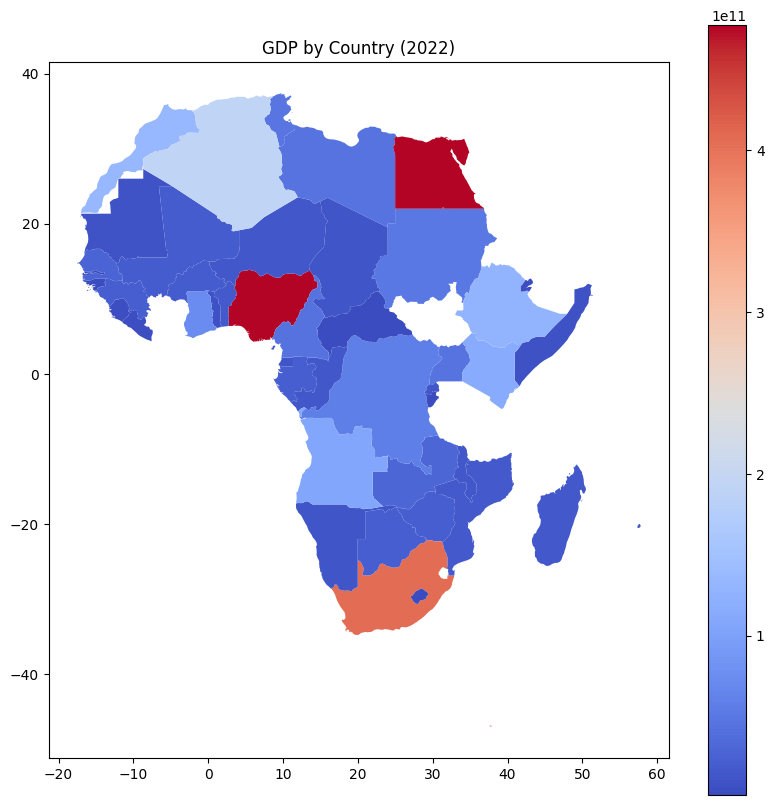

In [25]:
fig, ax= plt.subplots(figsize = (10,10))
joined_data.plot(
    column = 'GDP (USD)',
    ax = ax,
    legend = True,
    cmap = 'coolwarm',
)
ax.set_title('GDP by Country (2022)')
plt.show()
